<a href="https://colab.research.google.com/github/ash-hensday/Probing-Wav2Vec2/blob/main/168proj_vectors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
### this might run an error for the sklearn module, but it still works when you run the code below so just keep moving

!pip install transformers torch soundfile librosa pandas sklearn numpy

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
import torch
import torchaudio
import IPython
import matplotlib.pyplot as plt
from torchaudio.utils import download_asset
from google.colab import files
import os
import pandas as pd
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
import pickle
import matplotlib.pyplot as plt

In [ ]:
## Feature Embedding Extraction using Wav2Vec2
# It will ask you to choose the files to upload and process. It's helpful if you have them in the Files in the tab on this notebook, or you can just have them in a folder on your local machine.

# Set the random seed for reproducibility
torch.random.manual_seed(0)

# Determine the device to use (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the Wav2Vec2 model
bundle = torchaudio.pipelines.WAV2VEC2_BASE
model = bundle.get_model().to(device)

# Upload WAV files
uploaded = files.upload()

# Find the maximum length of the waveforms
max_length = 0
waveforms = []
for filename in uploaded.keys():
    waveform, sample_rate = torchaudio.load(filename)
    if sample_rate != bundle.sample_rate:
        waveform = torchaudio.functional.resample(waveform, sample_rate, bundle.sample_rate)
    waveforms.append(waveform)
    max_length = max(max_length, waveform.shape[1])

# Initialize an empty list to store feature vectors and filenames
data = []

# Iterate over each uploaded WAV file and its corresponding waveform
for filename, waveform in zip(uploaded.keys(), waveforms):
    # Pad the waveform to the maximum length
    pad_size = max_length - waveform.shape[1]
    if pad_size > 0:
        waveform = torch.nn.functional.pad(waveform, (0, pad_size))

    waveform = waveform.to(device)

    # Extract features using the Wav2Vec2 model
    with torch.inference_mode():
        features, _ = model.extract_features(waveform)

    # Convert the features to a numpy array and flatten it
    features_np = features[0].cpu().numpy().flatten()

    cleaned_filename = filename.replace('(3).wav', '')

    # Append the filename and features to the data list
    data.append([cleaned_filename] + features_np.tolist())


Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960.pth" to /root/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960.pth
100%|██████████| 360M/360M [00:02<00:00, 138MB/s]


Saving atliberty_nottalking.wav to atliberty_nottalking.wav
Saving benshapiro_datavpn_edited2.wav to benshapiro_datavpn_edited2.wav
Saving bestfriends_somenoise.wav to bestfriends_somenoise.wav
Saving brunch_badconfusing.wav to brunch_badconfusing.wav
Saving brunch_nervous.wav to brunch_nervous.wav
Saving candace_catchesher.wav to candace_catchesher.wav
Saving candace_hugebusiness.wav to candace_hugebusiness.wav
Saving candace_reallyinteresting.wav to candace_reallyinteresting.wav
Saving candace_thekids.wav to candace_thekids.wav
Saving cj_excited.wav to cj_excited.wav
Saving codeswitch_lesslikely.wav to codeswitch_lesslikely.wav
Saving codeswitch_needhelp.wav to codeswitch_needhelp.wav
Saving codeswitch_remind.wav to codeswitch_remind.wav
Saving coffeeconvos_best.wav to coffeeconvos_best.wav
Saving coffeeconvos_prettygood.wav to coffeeconvos_prettygood.wav
Saving dykingout_afterwards.wav to dykingout_afterwards.wav
Saving dykingout_alwaysbeenthere.wav to dykingout_alwaysbeenthere.wav


In [ ]:
# create a data frame from the list
# this dataframe contains all of the label information: speakers as .wav filenames, and the two ratings. Each row is a speaker, the two ratings, and then the entire embedding from Wav2Vec2

df = pd.DataFrame(data)

labels_df = pd.read_csv('/content/labels.csv')

df.reset_index(drop=True, inplace=True)
labels_df.reset_index(drop=True, inplace=True)

df_concat = pd.concat([labels_df, df], axis=1, ignore_index=True)
df_concat = df_concat.drop([3,4], axis=1)

In [ ]:
# dropping rows with NaN
df_concat = df_concat.dropna()

In [ ]:
### prep data for the classifier by separating labels and embeddings into different variables

embeddings = df_concat.iloc[:, 3:].values  # Assuming embeddings are all columns after 3rd column

gender_labels = df_concat.iloc[:, 1].values ## labels from just the gender column
so_labels = df_concat.iloc[:, 2].values ## labels from just the sexual orientation column
filename_labels = df_concat.iloc[:, 0].values ## all the files in order

gender_labels = gender_labels.reshape(-1, 1) # reshaping because there was an error that said to do this if there's only one feature, which is true
so_labels = so_labels.reshape(-1, 1)

In [ ]:
### classifier functions
# The following functions: preprocess the labels and embeddings (mostly just scaling); train and test the classifier using a Leave-One-Out method; and calculate RMSE.

# Preprocess data
def preprocess_data(embeddings, labels):

  scaler_embeddings = StandardScaler()
  embeddings_scaled = scaler_embeddings.fit_transform(embeddings)

  scaler_labels = MinMaxScaler(feature_range=(-1.5, 1.5))
  labels_scaled = scaler_labels.fit_transform(labels.reshape(-1, 1)).flatten()

  return embeddings_scaled, labels_scaled

# Train and evaluate the classifier with Leave-One-Out cross-validation
def train_and_evaluate_classifier(embeddings, labels):
    loo = LeaveOneOut()
    predictions = []
    true_values = []
    for train_index, test_index in loo.split(embeddings):
        X_train, X_test = embeddings[train_index], embeddings[test_index]
        y_train, y_test = labels[train_index], labels[test_index]

        classifier = SVR(kernel='linear', max_iter=10000)
        classifier.fit(X_train, y_train.ravel())

        y_pred = classifier.predict(X_test)

        predictions.append(y_pred[0])
        true_values.append(y_test[0])

    return np.array(predictions), np.array(true_values)

# Calculate RMSE
def calculate_rmse(predictions, true_values):
    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    return rmse


In [ ]:
# Main function to call in order to implement the defined functions above and create pickled files of the results for each condition
# this should output the results below after it has run

def main():
    # file_path = 'path_to_your_csv_file.csv'
    # embeddings, labels1, labels2 = load_data(file_path)
    # embeddings = preprocess_data(embeddings, label)

    results = {}

    for i, labels in enumerate([gender_labels, so_labels], 1):

        embeddings_scaled, labels_scaled = preprocess_data(embeddings, labels)

        # Suppress convergence warnings
        #with warnings.catch_warnings():
            #warnings.simplefilter("ignore", category=ConvergenceWarning)
        predictions, true_values = train_and_evaluate_classifier(embeddings_scaled, labels_scaled)

        rmse = calculate_rmse(predictions, true_values)

        print(f"Label Set {i} - Root Mean Squared Error:", rmse)
        print(f"Label Set {i} - Predicted values:", predictions)
        print(f"Label Set {i} - True values:", true_values)

        # Save results to a file
        results_filename = f'results_label_set_{i}.pkl'
        with open(results_filename, 'wb') as f:
            pickle.dump((rmse, predictions, true_values), f)

        results[f'label_set_{i}'] = (rmse, predictions, true_values)

    return results

if __name__ == "__main__":
    results = main()


Label Set 1 - Root Mean Squared Error: 0.8922042629466291
Label Set 1 - Predicted values: [ 0.42879984 -0.071935    0.21060763 -0.27385736 -0.53045812  0.96551649
  0.0945096   0.95898279 -0.21176801 -0.15128127 -0.41861441  0.6433438
  0.02785918  0.40433232  0.44098409  0.56762832 -0.00629439 -0.01460729
  0.52349759  0.58812093 -0.0853149   0.64762704  0.22373122  0.54090539
  0.6053531  -0.56648448 -0.53837242  0.89838118  1.02510944  0.11343205
 -0.61894466  0.51484411  0.19778624 -0.09451492 -0.36818839  0.03673309
 -0.71646284 -0.108289   -0.57027231  0.64267388 -0.03293984  0.72032307
  0.96623559  0.08168012 -0.22321905 -0.63151803 -0.13739037  0.57134924
 -0.76275396 -0.581706   -0.06036125 -0.26514967  0.14631441  0.67354874
 -0.44660515 -0.84308722  0.4568458  -0.27699988  0.2162663  -0.42372643]
Label Set 1 - True values: [ 0.96434619 -1.0809031   1.17742239 -1.39698965 -1.19943556  1.25305738
  1.39021637  1.40009407 -1.5        -1.28861712 -1.40122295  1.38146754
 -1.396

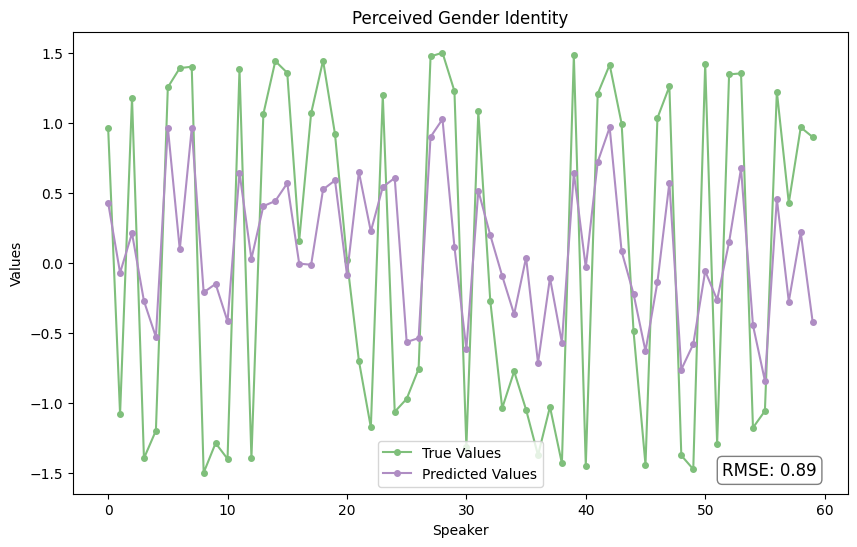

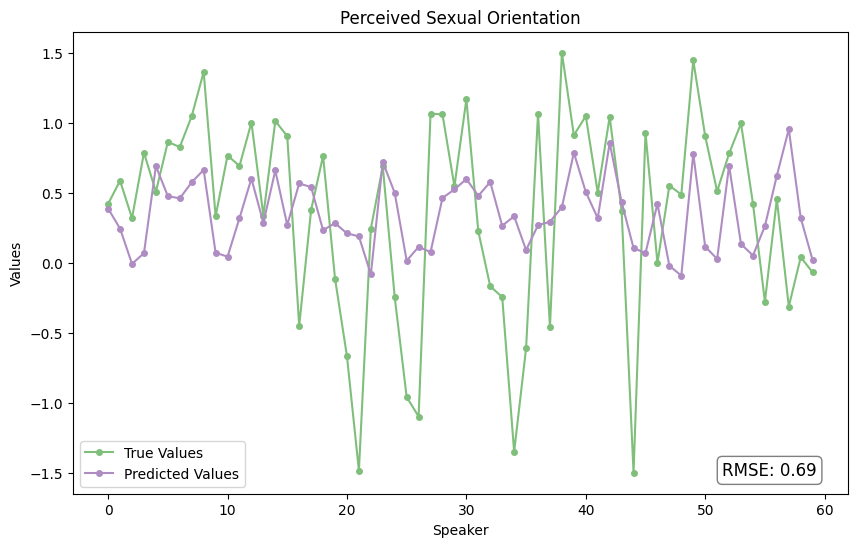

In [ ]:
### plotting
# these plots are line plots comparing the true and predicted values for each condition

# Function to plot results
def plot_results(true_values, predictions, rmse, label_set, title):
    plt.figure(figsize=(10, 6))

    # Plot true values with dots and lines
    plt.plot(range(len(true_values)), true_values, color='#7fbf7b', marker='o', linestyle='-', markersize=4, label='True Values')
    # Plot predicted values with dots and lines
    plt.plot(range(len(predictions)), predictions, color='#af8dc3', marker='o', linestyle='-', markersize=4, label='Predicted Values')

    plt.xlabel('Speaker')
    plt.ylabel('Values')
    plt.title(title)

    # Display RMSE in a textbox
    textstr = f'RMSE: {rmse:.2f}'
    props = dict(boxstyle='round', facecolor='w', alpha=0.5)
    plt.text(0.96, 0.07, textstr, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', horizontalalignment='right', bbox=props)

    fig_name = f'{title}.png'

    plt.legend()
    plt.savefig(fig_name, dpi=400, bbox_inches='tight')
    plt.show()

# Titles for each label set
titles = {
    1: "Perceived Gender Identity",
    2: "Perceived Sexual Orientation"
}

# Load and plot results for each label set
for i in range(1, 3):
    results_filename = f'results_label_set_{i}.pkl'
    with open(results_filename, 'rb') as f:
        rmse, predictions, true_values = pickle.load(f)

    plot_results(true_values, predictions, rmse, f'Label Set {i}', titles[i])



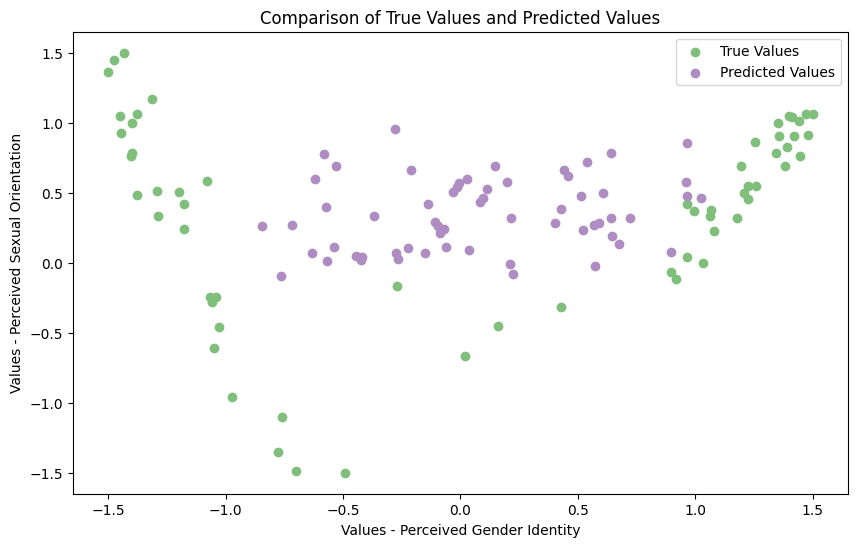

In [ ]:
# Function to plot comparison scatter plot
# this graph compares true and predicted values for both of the conditions in the same scatter plot


def plot_comparison(true_values_1, true_values_2, predictions_1, predictions_2, rmse_1, rmse_2):
    plt.figure(figsize=(10, 6))

    # Scatter plot for true values
    plt.scatter(true_values_1, true_values_2, color='#7fbf7b', label='True Values')
    # Scatter plot for predicted values
    plt.scatter(predictions_1, predictions_2, color='#af8dc3', label='Predicted Values')

    plt.xlabel('Values - Perceived Gender Identity')
    plt.ylabel('Values - Perceived Sexual Orientation')
    plt.title('Comparison of True Values and Predicted Values')

    # Display RMSE in a textbox
    # textstr = f'RMSE (Gender Identity): {rmse_1:.2f}\nRMSE (Sexual Orientation): {rmse_2:.2f}'
    # props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # plt.text(0.95, 0.15, textstr, transform=plt.gca().transAxes, fontsize=10,
    #          verticalalignment='top', horizontalalignment='right', bbox=props)

    plt.legend()
    plt.savefig('condition_comparison.png', dpi=400, bbox_inches='tight')
    plt.show()

# Load results for both label sets
with open('results_label_set_1.pkl', 'rb') as f:
    rmse_1, predictions_1, true_values_1 = pickle.load(f)

with open('results_label_set_2.pkl', 'rb') as f:
    rmse_2, predictions_2, true_values_2 = pickle.load(f)

# Plot the comparison scatter plot
plot_comparison(true_values_1, true_values_2, predictions_1, predictions_2, rmse_1, rmse_2)


<ipython-input-12-2a0910935b71>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(unique_labels))


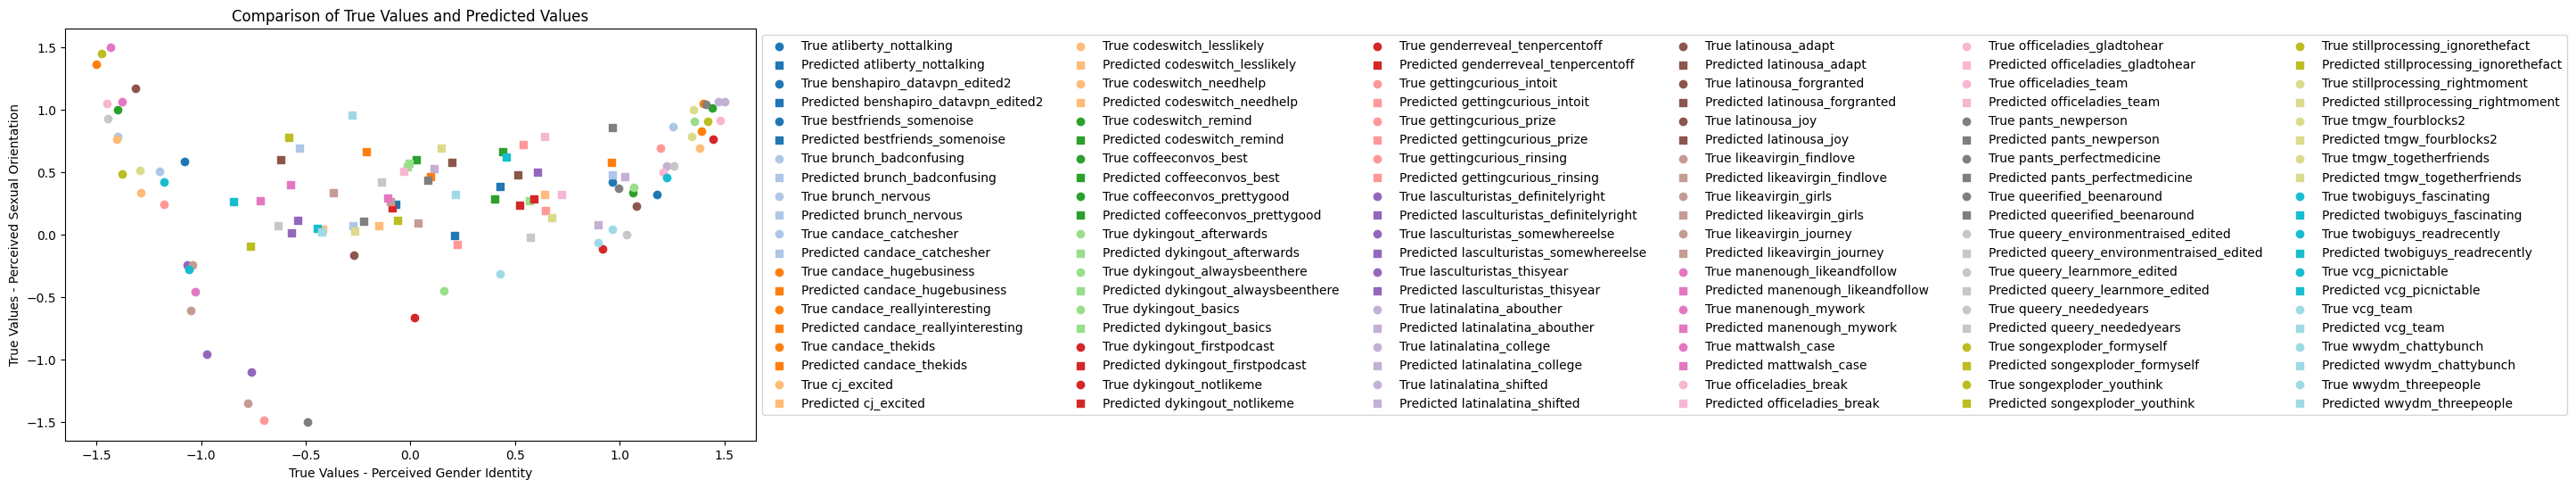

In [ ]:
# Function to plot comparison scatter plot with color-coded and shape-coded points
# this graph is just for Ben's curisoity and identifies where each true or predicted speaker shows up in the same two dimensional graph. enjoy for viewing pleasure.

def plot_comparison(true_values_1, true_values_2, predictions_1, predictions_2, filename_labels):
    plt.figure(figsize=(10, 6))

    unique_labels = np.unique(filename_labels)
    colors = plt.cm.get_cmap('tab20', len(unique_labels))

    markers_true = 'o'  # Marker for true values
    markers_pred = 's'  # Marker for predicted values

    for idx, label in enumerate(unique_labels):
        color = colors(idx)

        # Filter values for the current label
        indices = np.where(filename_labels == label)[0]

        true_vals_1 = true_values_1[indices]
        true_vals_2 = true_values_2[indices]
        pred_vals_1 = predictions_1[indices]
        pred_vals_2 = predictions_2[indices]

        # Plot true values
        plt.scatter(true_vals_1, true_vals_2, color=color, label=f'True {label}', marker=markers_true)
        # Plot predicted values
        plt.scatter(pred_vals_1, pred_vals_2, color=color, label=f'Predicted {label}', marker=markers_pred)

    plt.xlabel('True Values - Perceived Gender Identity')
    plt.ylabel('True Values - Perceived Sexual Orientation')
    plt.title('Comparison of True Values and Predicted Values')

    # Place the legend outside the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=6)

    # Save the plot as a .png file with 400 dpi
    plt.savefig('speaker_true_vs_predicted.png', dpi=400, bbox_inches='tight')
    plt.show()

# Load results for both label sets
with open('results_label_set_1.pkl', 'rb') as f:
    rmse_1, predictions_1, true_values_1 = pickle.load(f)

with open('results_label_set_2.pkl', 'rb') as f:
    rmse_2, predictions_2, true_values_2 = pickle.load(f)

# Plot the comparison scatter plot
plot_comparison(true_values_1, true_values_2, predictions_1, predictions_2, filename_labels)


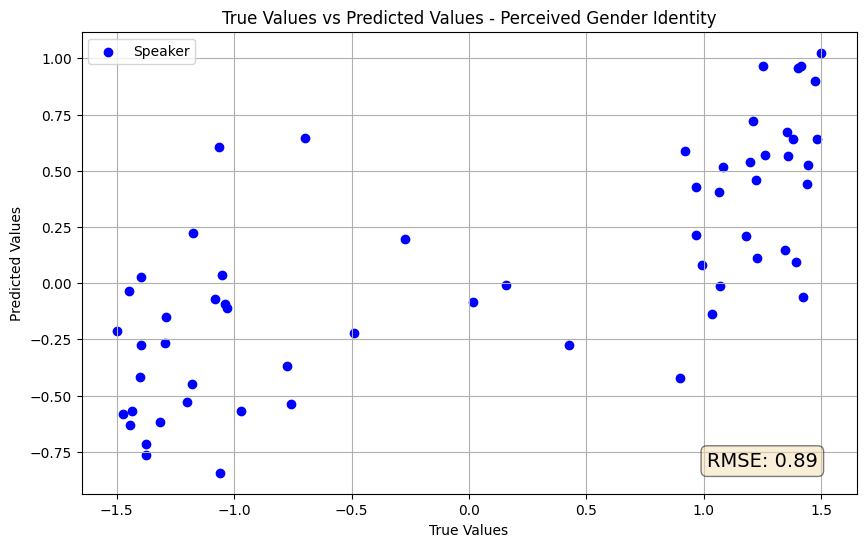

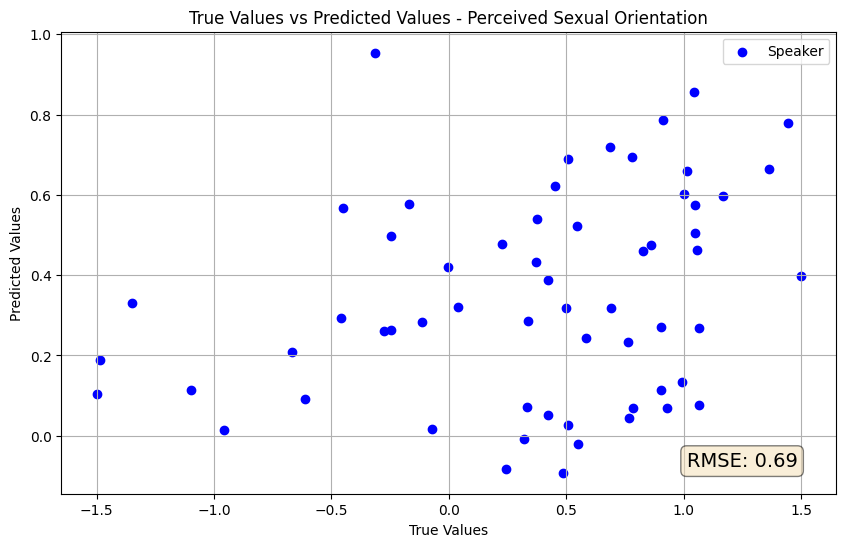

In [ ]:
# Function to plot true values vs. predictions with RMSE box
# this graph shows the true vs. predicted values for each condition with the calculated RMSE between those values reported for each condition

def plot_true_vs_predicted(true_values, predictions, rmse, title):
    plt.figure(figsize=(10, 6))

    # Scatter plot for true values vs. predicted values
    plt.scatter(true_values, predictions, color='blue', label='Speaker')

    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title(title)

    # Display RMSE in a textbox
    textstr = f'RMSE: {rmse:.2f}'
    props = dict(boxstyle='round', facecolor='w', alpha=0.5)
    plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes, fontsize=14,
             verticalalignment='bottom', horizontalalignment='right', bbox=props)

    plt.legend()
    plt.grid(True)
    plt.show()

# Load results for both label sets
with open('results_label_set_1.pkl', 'rb') as f:
    rmse_1, predictions_1, true_values_1 = pickle.load(f)

with open('results_label_set_2.pkl', 'rb') as f:
    rmse_2, predictions_2, true_values_2 = pickle.load(f)

# Plot the scatter plot for Label Set 1
plot_true_vs_predicted(true_values_1, predictions_1, rmse_1, 'True Values vs Predicted Values - Perceived Gender Identity')

# Plot the scatter plot for Label Set 2
plot_true_vs_predicted(true_values_2, predictions_2, rmse_2, 'True Values vs Predicted Values - Perceived Sexual Orientation')


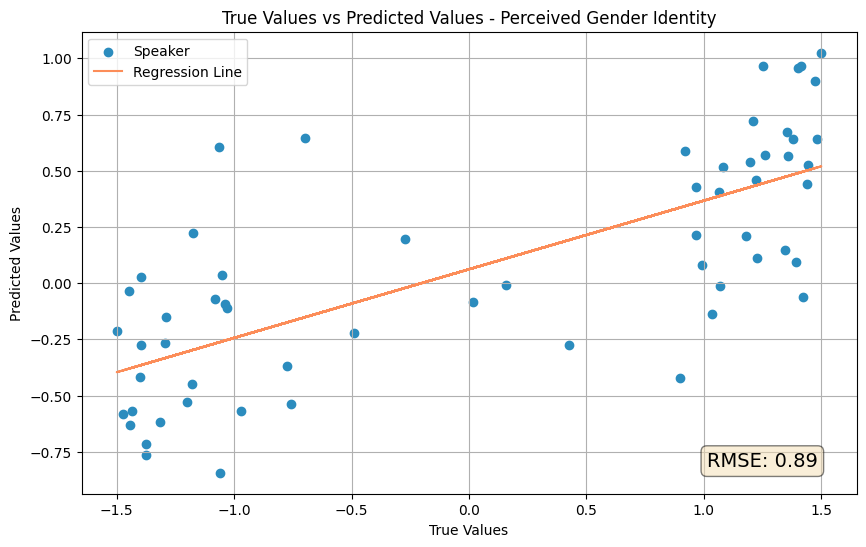

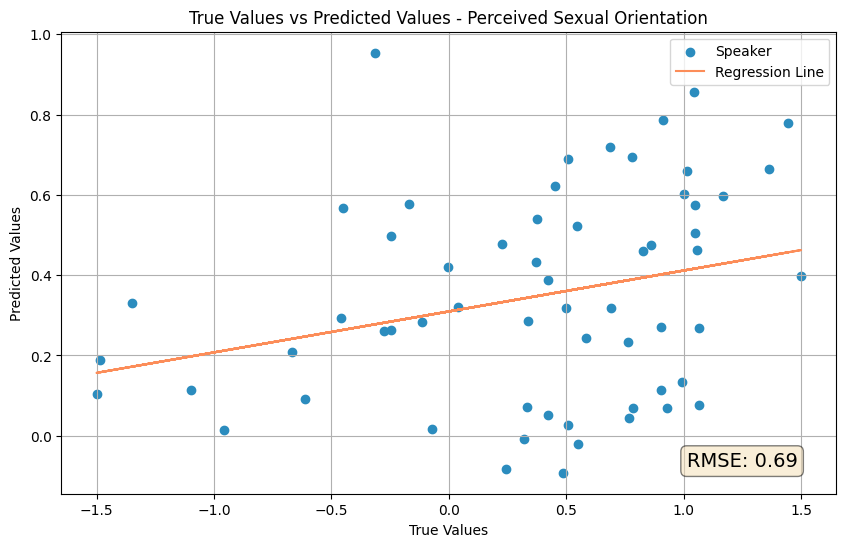

In [ ]:
# Function to plot true values vs. predictions with RMSE box and regression line
# this graph shows the true vs. predicted values for each condition as a function of a best fit linear regression, with the calculated RMSE between those values reported for each condition
# this is the same as the above graph, except now there's a line for reference


def plot_true_vs_predicted(true_values, predictions, rmse, title):
    plt.figure(figsize=(10, 6))

    # Scatter plot for true values vs. predicted values
    plt.scatter(true_values, predictions, color='#2b8cbe', label='Speaker')

    # Fit a linear regression line
    fit = np.polyfit(true_values, predictions, 1)
    fit_fn = np.poly1d(fit)

    # Plot the regression line
    plt.plot(true_values, fit_fn(true_values), color='#fc8d59', linestyle='-', label='Regression Line')

    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title(title)

    # Display RMSE in a textbox
    textstr = f'RMSE: {rmse:.2f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes, fontsize=14,
             verticalalignment='bottom', horizontalalignment='right', bbox=props)

    fig_name = f'{title}.png'

    plt.legend()
    plt.grid(True)
    plt.savefig(fig_name, dpi=400, bbox_inches='tight')
    plt.show()

# Load results for both label sets
with open('results_label_set_1.pkl', 'rb') as f:
    rmse_1, predictions_1, true_values_1 = pickle.load(f)

with open('results_label_set_2.pkl', 'rb') as f:
    rmse_2, predictions_2, true_values_2 = pickle.load(f)

# Plot the scatter plot for Label Set 1
plot_true_vs_predicted(true_values_1, predictions_1, rmse_1, 'True Values vs Predicted Values - Perceived Gender Identity')

# Plot the scatter plot for Label Set 2
plot_true_vs_predicted(true_values_2, predictions_2, rmse_2, 'True Values vs Predicted Values - Perceived Sexual Orientation')


In [ ]:
!kill -9 -1